In [17]:
import torch
import torchvision
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("PyTorch :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("OpenCV :", cv2.__version__)
print("NumPy :", np.__version__)
print("Pandas :", pd.__version__)

PyTorch : 2.13.0+cpu
Torchvision : 0.28.0+cpu
OpenCV : 5.0.0
NumPy : 2.5.1
Pandas : 3.0.5


In [18]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [19]:
dataset_path = "../dataset/TrashNet"

print(dataset_path)

../dataset/TrashNet


In [20]:
classes = sorted(os.listdir(dataset_path))

print(classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [21]:
print("Jumlah kelas:", len(classes))

Jumlah kelas: 5


In [22]:
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    total = len(os.listdir(folder))
    print(f"{cls:<12} : {total} gambar")

cardboard    : 403 gambar
glass        : 501 gambar
metal        : 410 gambar
paper        : 594 gambar
plastic      : 156 gambar


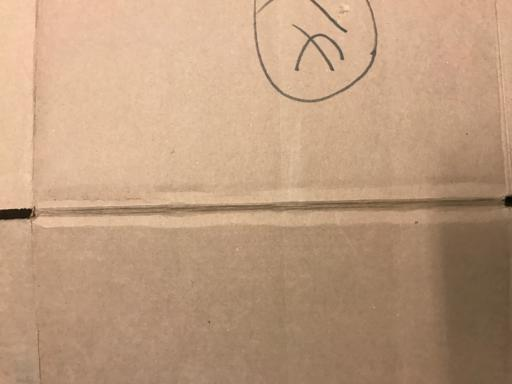

In [23]:
sample_class = classes[0]

sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

image_path = os.path.join(sample_folder, sample_image)

image = Image.open(image_path)

image

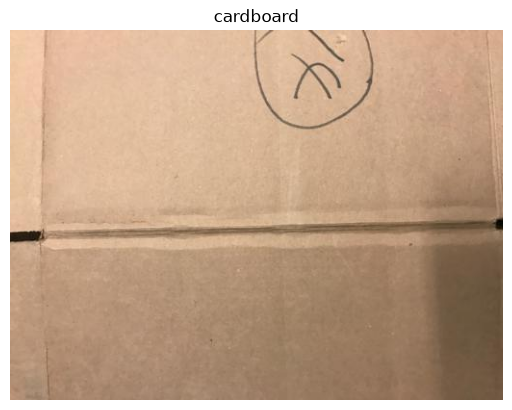

In [24]:
plt.imshow(image)
plt.title(sample_class)
plt.axis("off")
plt.show()

In [25]:
print(image.size)

(512, 384)


In [26]:
print(image.mode)

RGB


In [27]:
image_array = np.array(image)

print(image_array.shape)

(384, 512, 3)


In [28]:
print(image_array.min())
print(image_array.max())

0
253


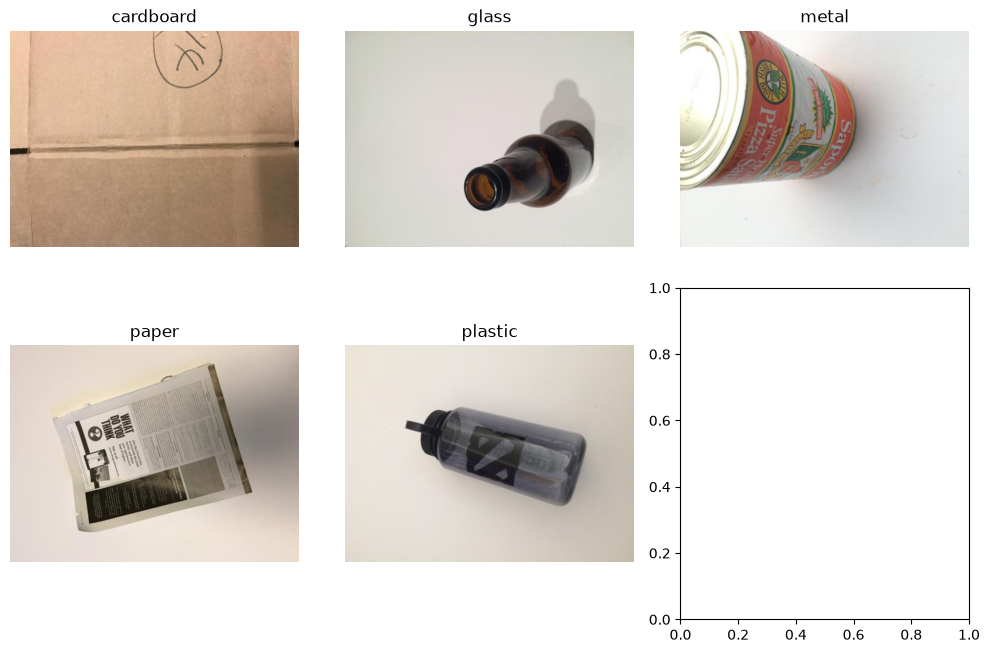

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, cls in zip(axes.flat, classes):
    folder = os.path.join(dataset_path, cls)

    img_name = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder, img_name))

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Jumlah kelas : {len(classes)}")

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    print(f"{cls:<12} : {len(os.listdir(folder))} gambar")

DATASET SUMMARY
Jumlah kelas : 5
cardboard    : 403 gambar
glass        : 501 gambar
metal        : 410 gambar
paper        : 594 gambar
plastic      : 156 gambar


In [31]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

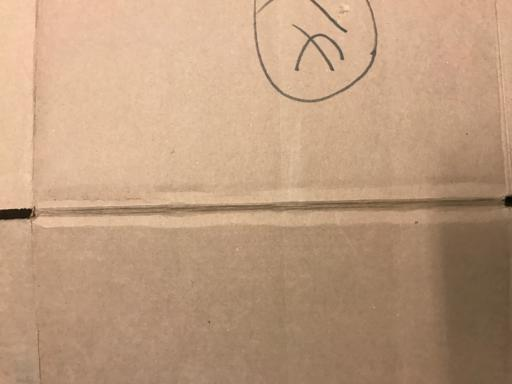

In [32]:
dataset_path = "../dataset/TrashNet"

classes = sorted(os.listdir(dataset_path))

sample_class = classes[0]

sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

image_path = os.path.join(sample_folder, sample_image)

image = Image.open(image_path)

image

In [33]:
resize = transforms.Resize((224, 224))

resized_image = resize(image)

print(resized_image.size)

(224, 224)


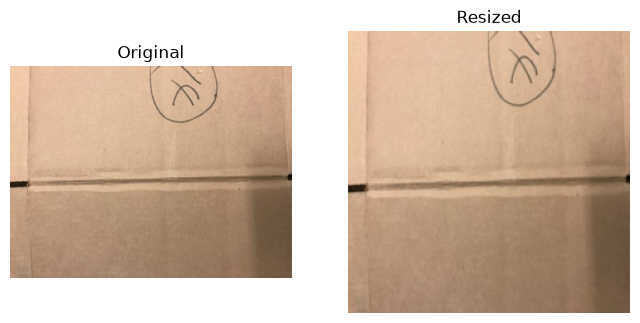

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(resized_image)
ax[1].set_title("Resized")
ax[1].axis("off")

plt.show()

In [35]:
to_tensor = transforms.ToTensor()

tensor_image = to_tensor(resized_image)

print(type(tensor_image))

<class 'torch.Tensor'>


In [36]:
print(tensor_image.shape)

torch.Size([3, 224, 224])


In [37]:
print(tensor_image.min())
print(tensor_image.max())

tensor(0.0118)
tensor(0.9725)


In [38]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
tensor_image = transform(image)

print(tensor_image.shape)

torch.Size([3, 224, 224])


In [40]:
print(tensor_image.min())
print(tensor_image.max())

tensor(-1.9467)
tensor(2.1290)


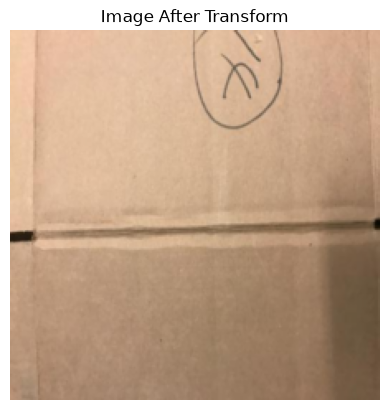

In [41]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = tensor_image.permute(1, 2, 0).numpy()

img = (img * std) + mean

img = np.clip(img, 0, 1)

plt.imshow(img)
plt.axis("off")
plt.title("Image After Transform")
plt.show()

In [42]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [43]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [44]:
dataset = ImageFolder(
    root="../dataset/TrashNet",
    transform=transform
)

In [45]:
print(dataset)

Dataset ImageFolder
    Number of datapoints: 2064
    Root location: ../dataset/TrashNet
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [46]:
print(dataset.classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic']


In [47]:
print(dataset.class_to_idx)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4}


In [48]:
print(len(dataset))

2064


In [49]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


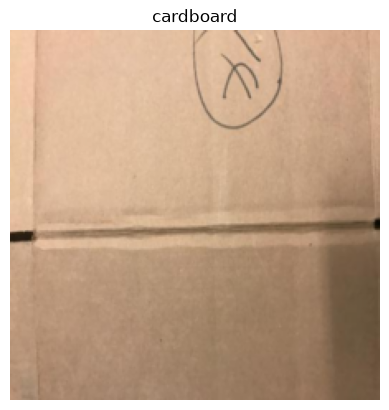

In [50]:
import numpy as np
import matplotlib.pyplot as plt

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

img = image.permute(1,2,0).numpy()

img = img * std + mean

img = np.clip(img,0,1)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [51]:
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [52]:
print(len(train_dataset))
print(len(val_dataset))

1651
413


In [53]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [54]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [55]:
print(labels)

tensor([0, 4, 3, 1, 2, 1, 3, 1, 3, 2, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 2, 1, 0, 3,
        3, 3, 4, 4, 4, 2, 1, 0])


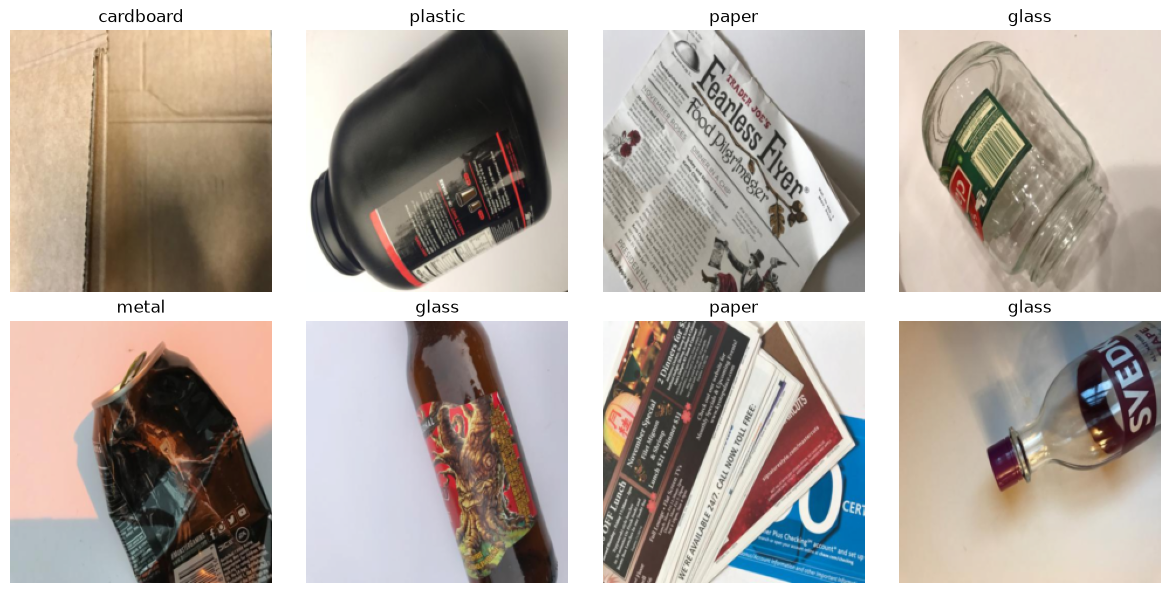

In [56]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()